# QPE

### $$ U |u\rangle = e^{2\pi i\omega} |u\rangle $$

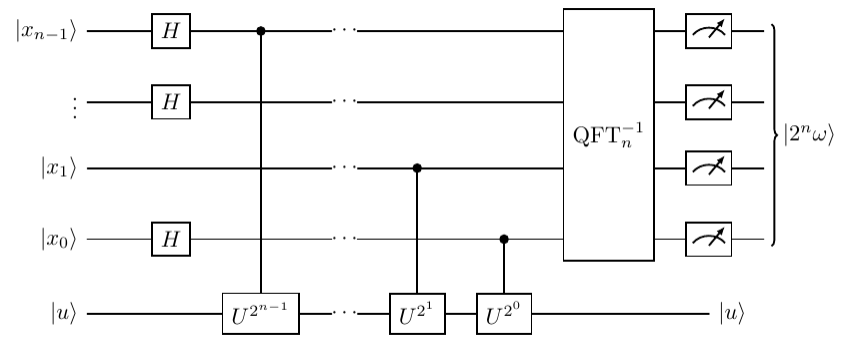

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

from qiskit.circuit.library import TGate, QFT

import numpy as np

## Visualizatin function

In [3]:
def qplot(x):
    return x.draw(scale=0.1, fold=-1, cregbundle=True, initial_state=True)

# S-gate

## $$ U = S = 
\begin{pmatrix}
1 & 0 \\
0 & e^{\frac{i\pi}{2}}
\end{pmatrix} \rightarrow 2\pi i\omega = \frac{\pi i}{2} \to \omega = \frac{1}{4} = 0.01
$$

In [13]:
# create the quantum Registers
qm = QuantumRegister(2, name = 'qubits')
qa = QuantumRegister(1, name = 'ancilla')
cbits = ClassicalRegister(2, name = 'cbits')

qc = QuantumCircuit(qm, qa, cbits)

# Building |u> = |1> in ancillary qubit
qc.x(qa)
qc.barrier(label = '|1>')

# Applying Hadamard
qc.h(qm)


# Applying CS gates on MSB (q_q)
for _ in range(2):
    qc.cs(qm[1], qa)

# Applying CS gates on LSB (q_0)
qc.cs(qm[0], qa)

# Applying QFT inverse
qc.append(QFT(2).inverse(), [0,1])

# Measurement
qc.measure(qm, cbits)

qplot(qc)


|1> ┌───┐               ┌───────┐┌─┐   
qubits_0: |0>───────░──┤ H ├────────────■──┤0      ├┤M├───
                    ░  ├───┤            │  │  IQFT │└╥┘┌─┐
qubits_1: |0>───────░──┤ H ├──■────■────┼──┤1      ├─╫─┤M├
             ┌───┐  ░  └───┘┌─┴─┐┌─┴─┐┌─┴─┐└───────┘ ║ └╥┘
 ancilla: |0>┤ X ├──░───────┤ S ├┤ S ├┤ S ├──────────╫──╫─
             └───┘  ░       └───┘└───┘└───┘          ║  ║ 
  cbits: 0 2/════════════════════════════════════════╩══╩═
                                                     0  1

In [15]:
backend = QasmSimulator()
t_qc = transpile(qc, backend)
job = backend.run(t_qc, shots = 1)
result = job.result()
counts = result.get_counts()
counts

{'01': 1}

# T-gate

## $$ T = 
\begin{pmatrix}
1 & 0 \\
0 & e^{\frac{i\pi}{4}}
\end{pmatrix} \rightarrow 2\pi i\omega = \frac{\pi i}{4} \to \omega =  \frac{1}{8} = 0.001
$$

In [29]:
n = 3

# create the main register
qm = QuantumRegister(n, name = 'qubits')
cbits = ClassicalRegister(n, name = 'cbits')

qc = QuantumCircuit(qm, qa, cbits)

# Building the staet vector |u> = |1>
qc.x(qa)
qc.barrier(label = '|1>')

# Applying Hadamard on main register
qc.h(qm)
qc.barrier(label = 'H^3')

# Applying control t gates on ancillar qubit
for i in range(n):
    for k in range(2**((n-1)-i)):
        qc.append(TGate().control(1), [qm[(n-1)-i],qa])



# Applyig QFT inverse on main register
qc.append(QFT(n).inverse(), [0,1,2])

# Measurement
qc.measure(qm, cbits)



qplot(qc)


|1> ┌───┐ H^3                                    ┌───────┐┌─┐      
qubits_0: |0>───────░──┤ H ├──░──────────────────────────────────■──┤0      ├┤M├──────
                    ░  ├───┤  ░                                  │  │       │└╥┘┌─┐   
qubits_1: |0>───────░──┤ H ├──░────────────────────────■────■────┼──┤1 IQFT ├─╫─┤M├───
                    ░  ├───┤  ░                        │    │    │  │       │ ║ └╥┘┌─┐
qubits_2: |0>───────░──┤ H ├──░────■────■────■────■────┼────┼────┼──┤2      ├─╫──╫─┤M├
             ┌───┐  ░  └───┘  ░  ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐└───────┘ ║  ║ └╥┘
 ancilla: |0>┤ X ├──░─────────░──┤ T ├┤ T ├┤ T ├┤ T ├┤ T ├┤ T ├┤ T ├──────────╫──╫──╫─
             └───┘  ░         ░  └───┘└───┘└───┘└───┘└───┘└───┘└───┘          ║  ║  ║ 
  cbits: 0 3/═════════════════════════════════════════════════════════════════╩══╩══╩═
                                                                              0  1  2

In [30]:
t_qc = transpile(qc, backend)
job = backend.run(t_qc, shots = 1)
result = job.result()
counts = result.get_counts()
counts

{'001': 1}